# CIC-IDS-2017 — Exploratory Data Analysis

## 1. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)


## 2. Load all CSV files

In [6]:
DATA_DIR = '../data'  # adjust if your path is different

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024 / 1024
    print(f'  {f}  ({size_mb:.1f} MB)')

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)


In [7]:
# Load and merge all files
dfs = []
for f in csv_files:
    path = os.path.join(DATA_DIR, f)
    tmp = pd.read_csv(path, low_memory=False)
    tmp['source_file'] = f   # track which file each row came from
    dfs.append(tmp)
    print(f'Loaded {f}: {tmp.shape}')

df = pd.concat(dfs, ignore_index=True)
print(f'\nMerged shape: {df.shape}')

Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 80)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 80)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 80)
Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 80)
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 80)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 80)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 80)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 80)

Merged shape: (2830743, 80)


## 3. Fix known data quality issues FIRST

In [8]:
# Issue 1: column names have leading/trailing spaces
print('Before strip — sample column names:')
print(df.columns[:5].tolist())

df.columns = df.columns.str.strip()

print('\nAfter strip:')
print(df.columns[:5].tolist())

Before strip — sample column names:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets']

After strip:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']


In [9]:
# Issue 2: inf values (Flow Bytes/s and Flow Packets/s produce inf for zero-duration flows)
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()
inf_cols = inf_counts[inf_counts > 0]
print('Columns with inf values:')
print(inf_cols if len(inf_cols) > 0 else 'None found')

Columns with inf values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [10]:
# Issue 3: NaN values
nan_counts = df.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]
print('Columns with NaN values:')
print(nan_cols if len(nan_cols) > 0 else 'None found')

Columns with NaN values:
Flow Bytes/s    1358
dtype: int64


In [11]:
# Fix: replace inf with NaN, then drop all NaN rows
rows_before = len(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
rows_after = len(df)

print(f'Rows before: {rows_before:,}')
print(f'Rows after:  {rows_after:,}')
print(f'Rows dropped: {rows_before - rows_after:,}')

Rows before: 2,830,743
Rows after:  2,827,876
Rows dropped: 2,867


## 4. Basic shape and dtypes

In [12]:
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\nData types:')
print(df.dtypes.value_counts())

Rows:    2,827,876
Columns: 80

Data types:
int64      54
float64    24
object      2
Name: count, dtype: int64


In [13]:
# Check for any non-numeric columns (besides Label and source_file)
obj_cols = df.select_dtypes(include='object').columns.tolist()
print('Object (non-numeric) columns:')
print(obj_cols)

Object (non-numeric) columns:
['Label', 'source_file']


## 5. Label distribution — the most important cell

In [14]:
label_counts = df['Label'].value_counts()
label_pct    = df['Label'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'count': label_counts,
    'percentage': label_pct.round(2)
})
print(label_summary.to_string())

                              count  percentage
Label                                          
BENIGN                      2271320     80.3200
DoS Hulk                     230124      8.1400
PortScan                     158804      5.6200
DDoS                         128025      4.5300
DoS GoldenEye                 10293      0.3600
FTP-Patator                    7935      0.2800
SSH-Patator                    5897      0.2100
DoS slowloris                  5796      0.2000
DoS Slowhttptest               5499      0.1900
Bot                            1956      0.0700
Web Attack � Brute Force       1507      0.0500
Web Attack � XSS                652      0.0200
Infiltration                     36      0.0000
Web Attack � Sql Injection       21      0.0000
Heartbleed                       11      0.0000


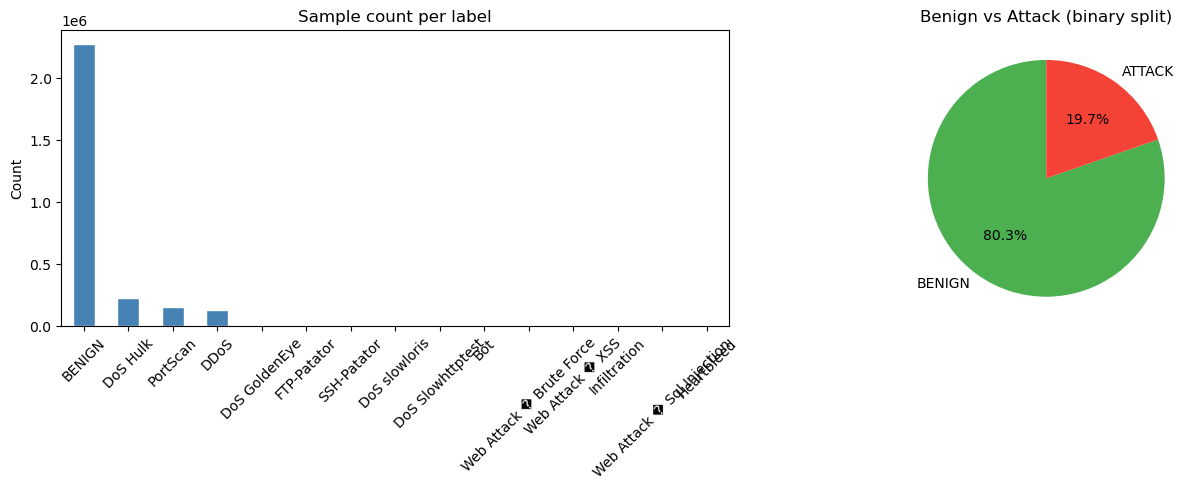

Saved to notebooks/label_distribution.png


In [15]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Sample count per label')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart (benign vs all attacks)
benign_count = label_counts.get('BENIGN', 0)
attack_count = label_counts.sum() - benign_count
axes[1].pie(
    [benign_count, attack_count],
    labels=['BENIGN', 'ATTACK'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
axes[1].set_title('Benign vs Attack (binary split)')

plt.tight_layout()
plt.savefig('../notebooks/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to notebooks/label_distribution.png')

## 6. Duplicate rows

In [16]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)')

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Dropped. New shape: {df.shape}')
else:
    print('No duplicates — no action needed.')

Duplicate rows: 255,236 (9.03%)
Dropped. New shape: (2572640, 80)


## 7. Feature statistics

In [17]:
# Summary stats for numeric features
numeric_df = df.drop(columns=['Label', 'source_file'], errors='ignore')
numeric_df.describe().T.sort_values('std', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2572640.0000,16257359.7650,34953760.7696,-13.0000,200.0000,48854.0000,5225583.2500,119999998.0000
Fwd IAT Total,2572640.0000,15924345.5215,34885081.0812,0.0000,1.0000,48.0000,4326274.5000,120000000.0000
Bwd IAT Total,2572640.0000,10886361.9974,29963804.3823,0.0000,0.0000,3.0000,147760.0000,120000000.0000
Flow Bytes/s,2572640.0000,1430298.4886,26356449.1703,-261000000.0000,119.9689,3960.5284,130434.7826,2071000000.0000
Fwd IAT Max,2572640.0000,9938547.1107,25545352.9841,0.0000,1.0000,48.0000,3797272.2500,120000000.0000
Flow IAT Max,2572640.0000,10092027.2716,25466376.8632,-13.0000,167.0000,40056.0000,4919946.2500,120000000.0000
Idle Max,2572640.0000,9567017.9676,25395120.4361,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Mean,2572640.0000,9149207.2401,24631517.2682,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Min,2572640.0000,8713471.9193,24364563.0271,0.0000,0.0000,0.0000,0.0000,120000000.0000
Fwd Header Length,2572640.0000,-28610.7279,22083695.2329,-32212234632.0000,40.0000,64.0000,144.0000,4644908.0000


In [18]:
# Near-zero variance features (these add noise, we'll drop them in preprocessing)
low_var = numeric_df.var()[numeric_df.var() < 0.01]
print(f'Near-zero variance features ({len(low_var)} found):')
print(low_var.index.tolist())

Near-zero variance features (12 found):
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## 8. Feature distributions — benign vs attack

In [19]:
# Binary label for plotting
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)

# Top features to visualize (most informative for intrusion detection)
key_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
]

# Filter to only features that exist in this dataset
key_features = [f for f in key_features if f in df.columns]
print(f'Plotting {len(key_features)} key features')

Plotting 12 key features


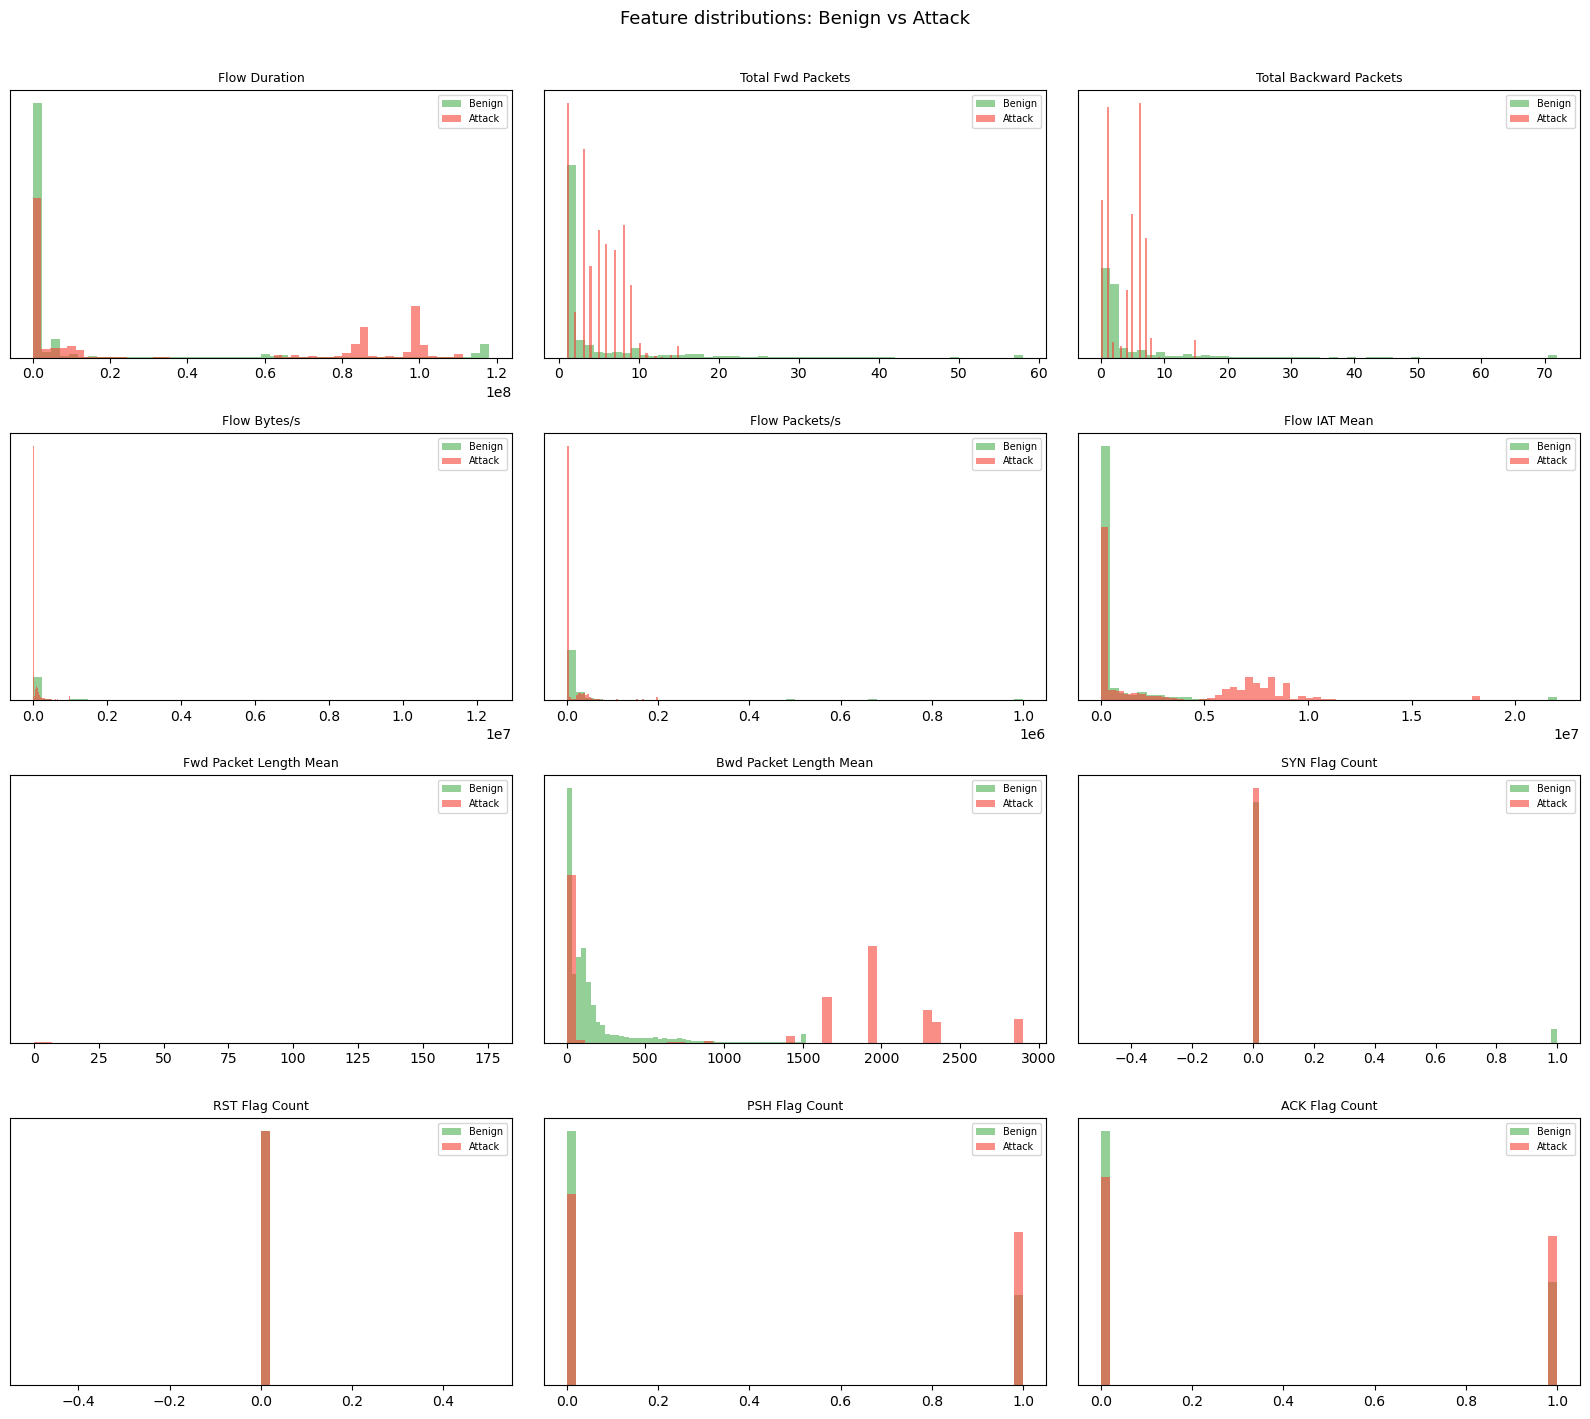

Saved to notebooks/feature_distributions.png


In [20]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

benign = df[df['binary_label'] == 0]
attack = df[df['binary_label'] == 1]

for i, feat in enumerate(key_features):
    axes[i].hist(benign[feat].clip(lower=benign[feat].quantile(0.01),
                                    upper=benign[feat].quantile(0.99)),
                 bins=50, alpha=0.6, color='#4CAF50', label='Benign', density=True)
    axes[i].hist(attack[feat].clip(lower=attack[feat].quantile(0.01),
                                    upper=attack[feat].quantile(0.99)),
                 bins=50, alpha=0.6, color='#F44336', label='Attack', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_yticks([])

# Hide unused subplots
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions: Benign vs Attack', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to notebooks/feature_distributions.png')

## 9. Correlation heatmap (top features only)

In [21]:
# Correlation with binary label — tells us which features are most useful
corr_with_label = numeric_df.corrwith(df['binary_label']).abs().sort_values(ascending=False)

print('Top 20 features most correlated with attack label:')
print(corr_with_label.head(20).round(4).to_string())

Top 20 features most correlated with attack label:
Bwd Packet Length Std    0.6132
Bwd Packet Length Max    0.5981
Bwd Packet Length Mean   0.5960
Avg Bwd Segment Size     0.5960
Packet Length Std        0.5753
Max Packet Length        0.5574
Packet Length Variance   0.5380
Average Packet Size      0.5234
Packet Length Mean       0.5228
Fwd IAT Std              0.5077
Idle Max                 0.4774
Flow IAT Max             0.4734
Fwd IAT Max              0.4727
Idle Mean                0.4726
Idle Min                 0.4602
Flow IAT Std             0.4130
Fwd IAT Total            0.2831
Flow Duration            0.2821
Min Packet Length        0.2786
FIN Flag Count           0.2723


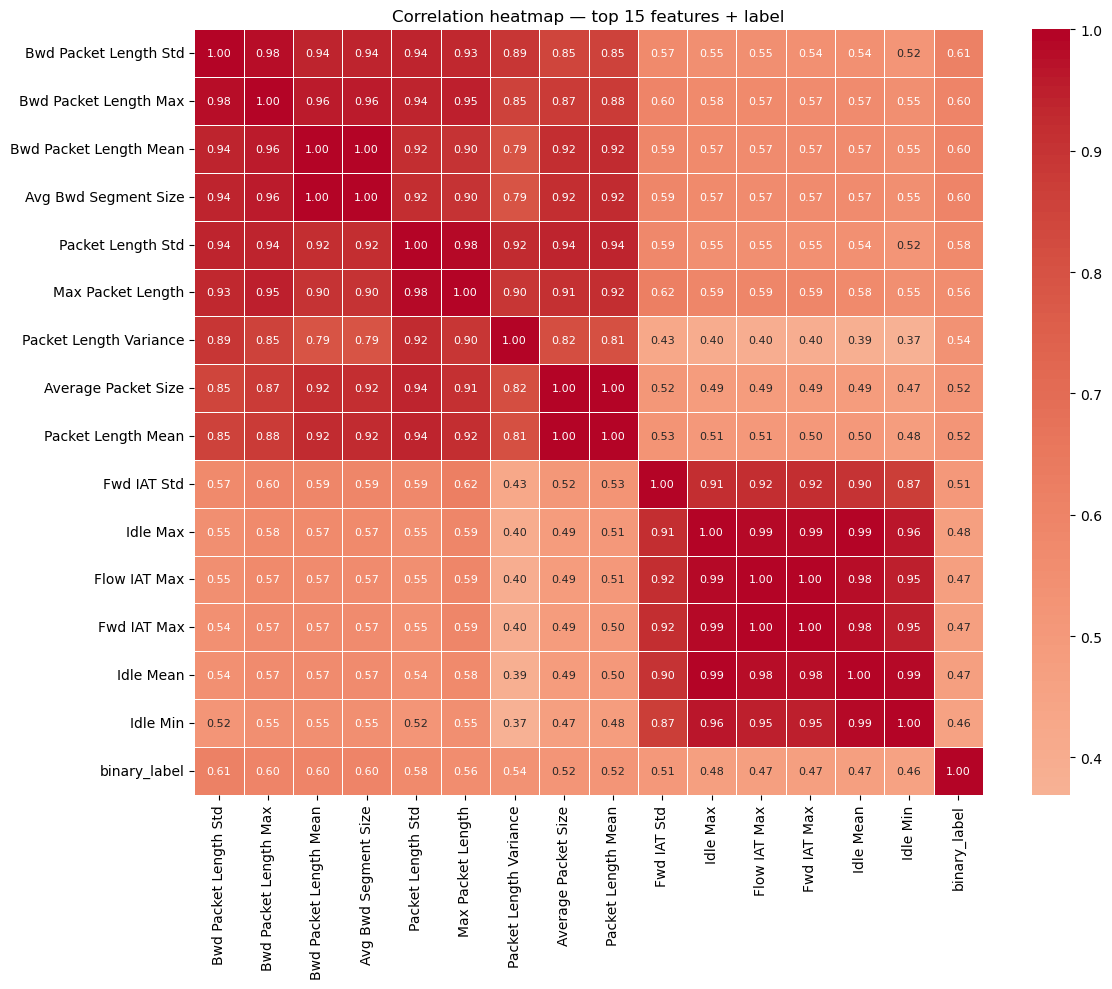

In [22]:
# Heatmap of top 15 features
top_features = corr_with_label.head(15).index.tolist()
top_features.append('binary_label')

plt.figure(figsize=(12, 10))
corr_matrix = df[top_features].corr()
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Correlation heatmap — top 15 features + label')
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-file label breakdown

In [23]:
# Which attacks appear in which files?
# Useful to know which CSVs to load for specific attack types
file_label = df.groupby(['source_file', 'Label']).size().unstack(fill_value=0)
print(file_label.to_string())

Label                                                        BENIGN   Bot    DDoS  DoS GoldenEye  DoS Hulk  DoS Slowhttptest  DoS slowloris  FTP-Patator  Heartbleed  Infiltration  PortScan  SSH-Patator  Web Attack � Brute Force  Web Attack � Sql Injection  Web Attack � XSS
source_file                                                                                                                                                                                                                                                                      
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv              95068     0  128014              0         0                 0              0            0           0             0         0            0                         0                           0                 0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         123083     0       0              0         0                 0              0            0           0             0

## 11. EDA summary

In [24]:
print('=== EDA SUMMARY ===')
print(f'Total rows (after cleaning):  {len(df):,}')
print(f'Total features:               {len(numeric_df.columns)}')
print(f'Number of label classes:      {df["Label"].nunique()}')
print(f'Benign rows:                  {(df["Label"]=="BENIGN").sum():,} ({(df["Label"]=="BENIGN").mean()*100:.1f}%)')
print(f'Attack rows:                  {(df["Label"]!="BENIGN").sum():,} ({(df["Label"]!="BENIGN").mean()*100:.1f}%)')
print(f'Near-zero variance features:  {len(low_var)}')
print(f'\nTop 5 features by label correlation:')
print(corr_with_label.head(5).round(4).to_string())

=== EDA SUMMARY ===
Total rows (after cleaning):  2,572,640
Total features:               78
Number of label classes:      15
Benign rows:                  2,146,899 (83.5%)
Attack rows:                  425,741 (16.5%)
Near-zero variance features:  12

Top 5 features by label correlation:
Bwd Packet Length Std    0.6132
Bwd Packet Length Max    0.5981
Bwd Packet Length Mean   0.5960
Avg Bwd Segment Size     0.5960
Packet Length Std        0.5753


## 12. Save cleaned dataframe
Save a cleaned version so `train.py` doesn't need to redo all this.

In [25]:
# Drop helper columns before saving
df_clean = df.drop(columns=['source_file', 'binary_label'], errors='ignore')

out_path = '../data/cleaned.csv'
df_clean.to_csv(out_path, index=False)
print(f'Saved cleaned dataset to {out_path}')
print(f'Shape: {df_clean.shape}')

Saved cleaned dataset to ../data/cleaned.csv
Shape: (2572640, 79)
